# Project

## Loading the dataset

In [1]:
import glob
from typing import Tuple
import polars as pl
import pandas as pd
import os

In [2]:
DATA_ROOT = "data"

In [3]:
def get_labels_from_filename(filename: str) -> Tuple[str, str, bool]:
    if "Benign" in filename:
        return "Benign", "Benign", False

    if "ARP_Spoofing" in filename:
        return "ARP_Spoofing", "Spoofing", True

    if "Recon" in filename:
        category = "Recon"
        if "Recon-Ping_Sweep" in filename:
            return "Ping_Sweep", category, True
        if "Recon-VulScan" in filename:
            return "VulScan", category, True
        if "Recon-OS_Scan" in filename:
            return "OS_Scan", category, True
        if "Recon-Port_Scan" in filename:
            return "Port_Scan", category, True

    if "MQTT" in filename:
        category = "MQTT"
        if "MQTT-Malformed_Data" in filename:
            return "Malformed_Data", category, True
        if "MQTT-DoS-Connect_Flood" in filename:
            return "DoS_Connect_Flood", category, True
        if "MQTT-DDoS-Publish_Flood" in filename:
            return "DDoS_Publish_Flood", category, True
        if "MQTT-DoS-Publish_Flood" in filename:
            return "DoS_Publish Flood", category, True
        if "MQTT-DDoS-Connect_Flood" in filename:
            return "DDoS_Connect_Flood", category, True

    if "TCP_IP-DoS" in filename:
        category = "DoS"
        if "TCP_IP-DoS-TCP" in filename:
            return "DoS_TCP", category, True
        if "TCP_IP-DoS-ICMP" in filename:
            return "DoS_ICMP", category, True
        if "TCP_IP-DoS-SYN" in filename:
            return "DoS_SYN", category, True
        if "TCP_IP-DoS-UDP" in filename:
            return "DoS_UDP", category, True

    if "TCP_IP-DDoS" in filename:
        category = "DDoS"
        if "TCP_IP-DDoS-SYN" in filename:
            return "DDoS_SYN", category, True
        if "TCP_IP-DDoS-TCP" in filename:
            return "DDoS_TCP", category, True
        if "TCP_IP-DDoS-ICMP" in filename:
            return "DDoS_ICMP", category, True
        if "TCP_IP-DDoS-UDP" in filename:
            return "DDoS_UDP", category, True

    return "", "", False 

In [4]:
def combine_dataset_files(root: str, save_name: str = "combined_dataset") -> None:
    path = os.path.join(root,"*","*.csv")
    files = glob.glob(path, recursive=True)
    combined_dir = os.path.join(root, "combined")
    out_path = os.path.join(combined_dir, f"{save_name}.parquet")
    os.makedirs(combined_dir, exist_ok=True)

    frames = []
    with pl.StringCache():
        for file in files:
            name, category, attack = get_labels_from_filename(file)

            lf = pl.scan_csv(file)

            lf = lf.with_columns(
                [
                    pl.lit(name).alias("Name").cast(pl.Categorical),
                    pl.lit(category).alias("Category").cast(pl.Categorical),
                    pl.lit(attack).alias("Attack"),
                ]
            )

            frames.append(lf)

        combined_lf = pl.concat(frames)
        combined_lf.sink_parquet(out_path)

In [5]:
def load_dataset(save_name: str) -> pl.DataFrame:
    path = os.path.join(DATA_ROOT, "combined", f"{save_name}.parquet")
    if not os.path.exists(path):
        combine_dataset_files(DATA_ROOT, save_name)
    df = pl.read_parquet(path)
    return df

In [6]:
df = load_dataset("combined_dataset").with_columns(pl.col(pl.Float64).cast(pl.Float32)) # reducing memory usage

## Exploratory Data Analysis

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [8]:
sns.set_theme(style="darkgrid", context="paper", palette="bright")

In [9]:
def plot_attack_counts(data):
    attack_counts = data.group_by("Name").len().sort("len", descending=False)
    attack_counts = attack_counts.to_pandas()
    fig, ax = plt.subplots(figsize = (12,6))
    sns.barplot(x="Name", y="len", data= attack_counts, ax=ax)
    ax.set_title("Distribution of Attack Names (Entire Dataset)")
    ax.set_xlabel("Attack Name")
    ax.set_ylabel("Count")

    ax.set_xticklabels(
        ax.get_xticklabels(),
        rotation = 45,
        horizontalalignment="right",
        rotation_mode = "anchor"
    )

    plt.ticklabel_format(style = "plain", axis = "y")
    plt.tight_layout()

/tmp/ipykernel_948452/3936347908.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(


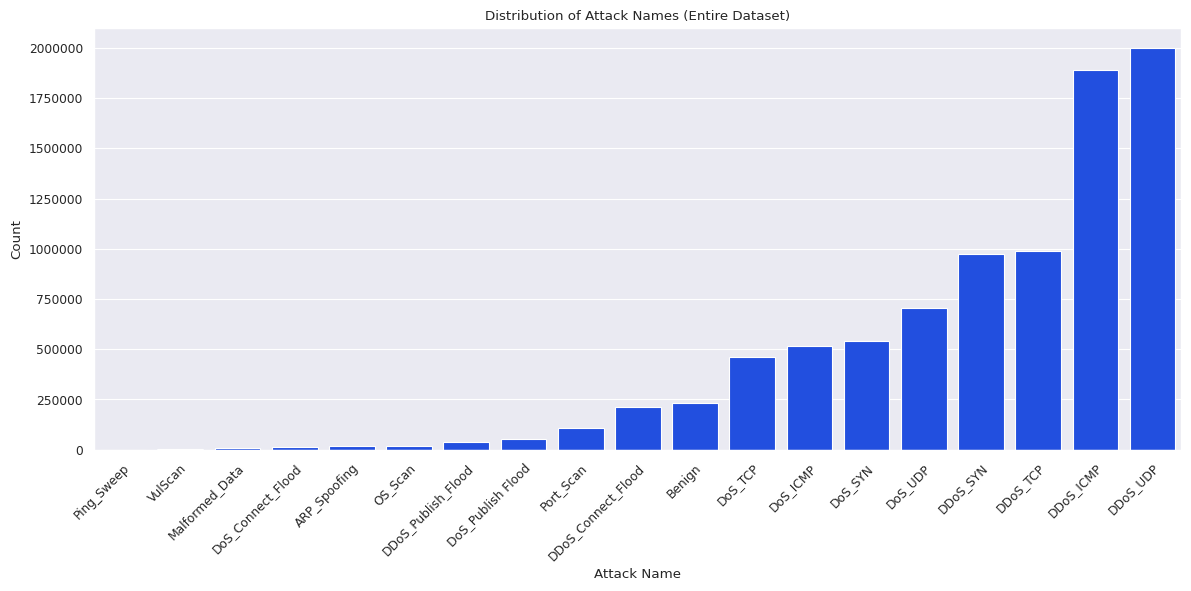

In [10]:
plot_attack_counts(df)

In [11]:
def plot_ddos_dos_bar(data):
    ddos_dos_counts = (
        data.filter(pl.col("Category").is_in(["DDoS", "DoS"]))
        .group_by("Category")
        .len()
        .sort("len", descending=False)
    )
    data = ddos_dos_counts.to_pandas()
    data.columns = ["Attack Type", "Count"]

    fig, ax = plt.subplots(figsize = (12,6))
    sns.barplot(x="Attack Type", y="Count", data=data, ax=ax)
    ax.set_title("Distribution of DDoS and DoS Attacks (Entire Dataset)")
    ax.set_xlabel("Attack Category")
    ax.set_ylabel("Count")

    ax.set_xticklabels(
        ax.get_xticklabels(),
        rotation = 45,
        horizontalalignment="right",
        rotation_mode = "anchor"
    )

    plt.ticklabel_format(style = "plain", axis = "y")
    plt.tight_layout()

/tmp/ipykernel_948452/1326252802.py:17: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(


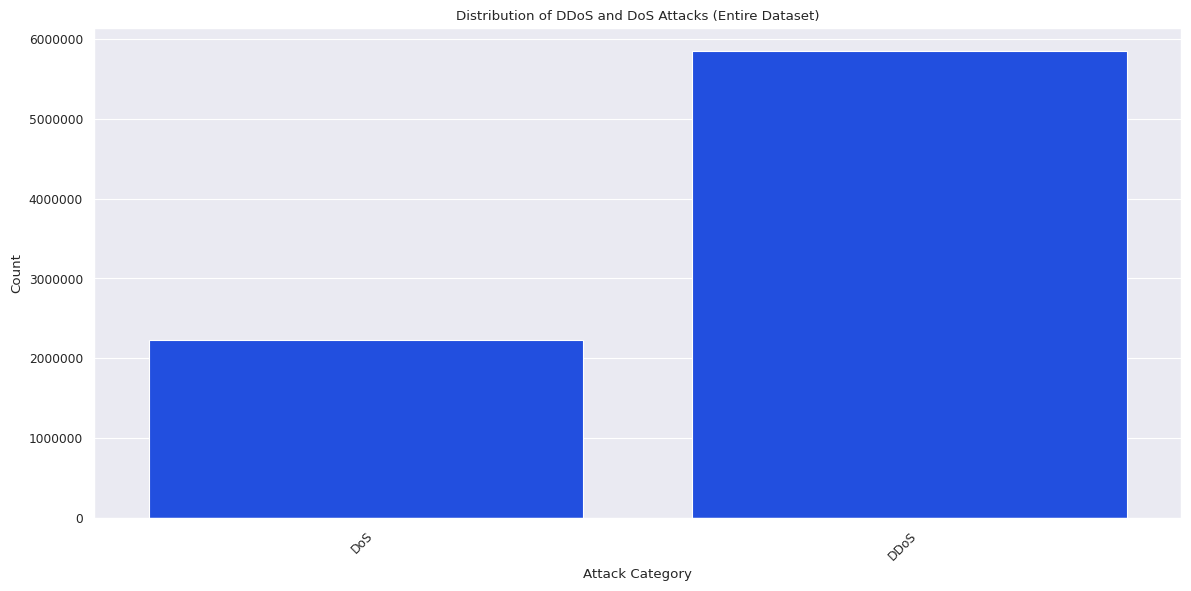

In [12]:
plot_ddos_dos_bar(df)

In [13]:
def plot_categories_no_ddos_dos(data):
    included_categories = ["MQTT", "Spoofing", "Recon", "Benign"]
    data = (
        data.filter(pl.col("Category").is_in(included_categories))
        .group_by("Category")
        .len()
        .sort("len", descending=False)
    ).to_pandas()

    fig, ax = plt.subplots(figsize = (12,6))
    sns.barplot(x="Category", y="len", data=data, ax=ax)
    ax.set_title("Distribution of Attack Categories (Excluding DDoS and DoS) (Entire Dataset)")
    ax.set_xlabel("Attack Category")
    ax.set_ylabel("Count")

    ax.set_xticklabels(
        ax.get_xticklabels(),
        rotation = 45,
        horizontalalignment="right",
        rotation_mode = "anchor"
    )

    plt.ticklabel_format(style = "plain", axis = "y")
    plt.tight_layout()

/tmp/ipykernel_948452/2949990234.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(


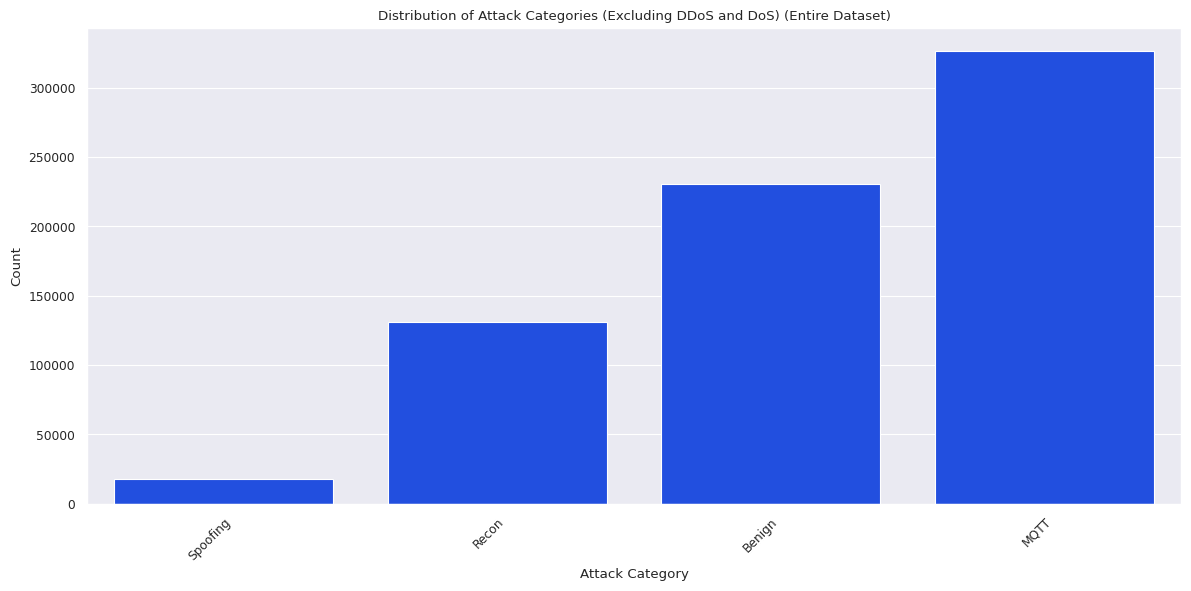

In [14]:
plot_categories_no_ddos_dos(df)

In [15]:
def plot_all_attack_categories_bar(data):
    data = data.group_by("Category").len().sort("len", descending=False).to_pandas()
    fig, ax = plt.subplots(figsize = (12,6))
    sns.barplot(x="Category", y="len", data=data, ax=ax)
    ax.set_title("Distribution of Attack Categories (Entire Dataset)")
    ax.set_xlabel("Attack Category")
    ax.set_ylabel("Count")

    ax.set_xticklabels(
        ax.get_xticklabels(),
        rotation = 45,
        horizontalalignment="right",
        rotation_mode = "anchor"
    )

    plt.ticklabel_format(style = "plain", axis = "y")
    plt.tight_layout()

/tmp/ipykernel_948452/1611355591.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(


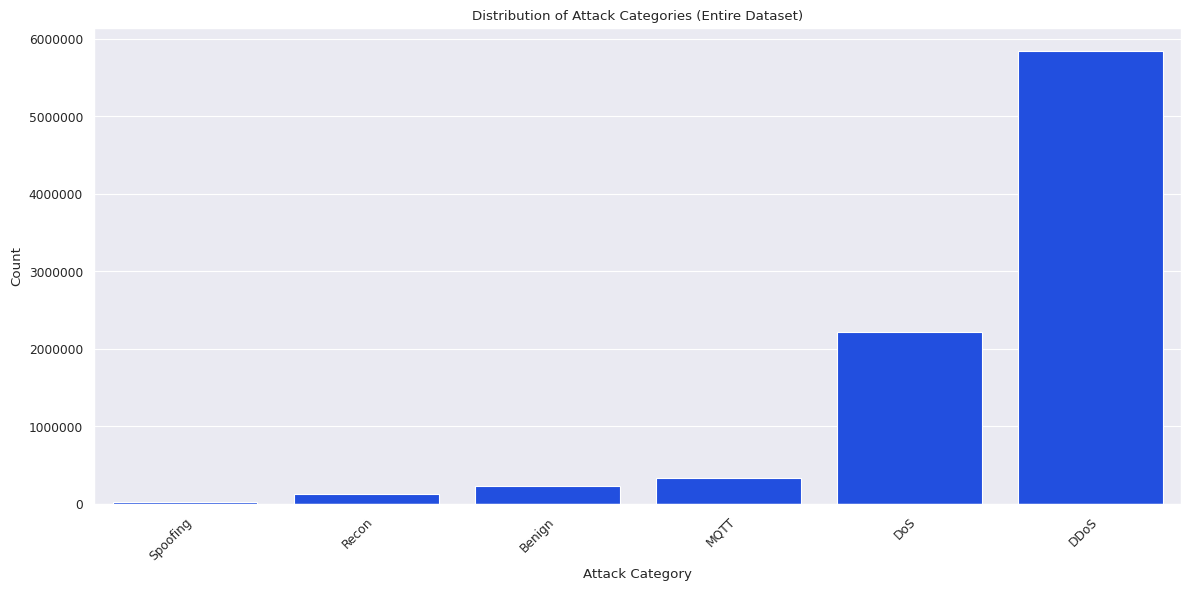

In [16]:
plot_all_attack_categories_bar(df)

In [17]:
def plot_attack_benign_pie(data):
    attack_counts = data.group_by("Attack").len().sort("len", descending=False)
    attack_counts = attack_counts.to_pandas()
    attack_counts.columns = ["Attack", "Count"]

    attack_counts = attack_counts.set_index("Attack")["Count"]
    total_count = attack_counts.sum()
    percentages = (attack_counts / total_count) * 100
    slices = attack_counts.values
    labels = attack_counts.index

    colours = sns.color_palette("hls", len(labels))

    fig, ax = plt.subplots()
    ax.set_title("Comparison between Benign and Attack Data (Entire Dataset)")
    plt.pie(
        slices,
        colors=colours,  
        wedgeprops=dict(edgecolor="black", linewidth=1),
        textprops=dict(color="white", fontsize=10),
        startangle=90,
    )

    legend_labels = [
        f"{label} ({percentage:.2f}%)"
        for label, percentage in zip(labels, percentages)
    ]
    ax.legend(
        legend_labels,
        title="Malicious Traffic?",
        loc="upper left",
        bbox_to_anchor=(1.02, 1.0),
    )

    plt.gca().set_aspect("equal")

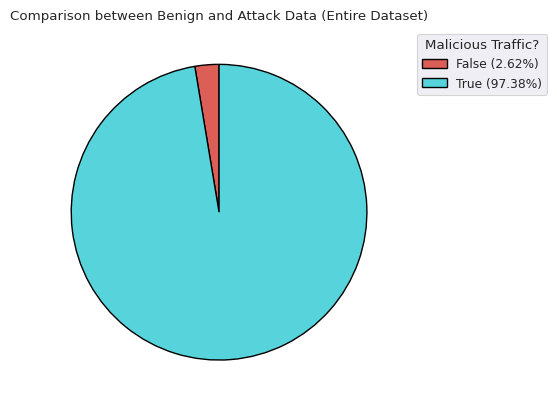

In [18]:
plot_attack_benign_pie(df)

In [19]:
def plot_breakdown_pie(data, title):
    target_column = "Category"
    attack_counts = data.group_by(target_column).len().sort(target_column)
    attack_counts = attack_counts.to_pandas()
    attack_counts.columns = [target_column, "Count"]

    attack_counts = attack_counts.set_index(target_column)["Count"]
    total_count = attack_counts.sum()
    percentages = (attack_counts / total_count) * 100
    slices = attack_counts.values
    labels = attack_counts.index

    fig, ax = plt.subplots()
    ax.set_title(title)
    colours = sns.color_palette("tab20", len(labels))
    plt.pie(
        slices,
        wedgeprops=dict(edgecolor="black", linewidth=1),
        textprops=dict(color="white", fontsize=10),
        startangle=90,
        colors=colours,
    )

    legend_labels = [
        f"{label} ({percentage:.2f}%)"
        for label, percentage in zip(labels, percentages)
    ]
    ax.legend(
        legend_labels,
        title=f"Attack {target_column}",
        loc="upper left",
        bbox_to_anchor=(1.02, 1.0),
    )

    plt.gca().set_aspect("equal")

In [20]:
def plot_correlation_heatmap(data):
    numeric_data = data.select(
        pl.exclude("Attack", "Category", "Name").name.map(lambda name: name.lower())
    )

    std_devs = numeric_data.select(pl.all().std())
    zer_var_cols = [col for col in std_devs.columns if std_devs[col][0] == 0]
    numeric_data = numeric_data.drop(zer_var_cols)

    corr = numeric_data.corr()
    corr_labels = corr.columns
    corr = corr.to_numpy()
    mask = np.triu(np.ones_like(corr, dtype=bool))

    fig, ax = plt.subplots(figsize=(15, len(corr_labels) // 2))
    sns.heatmap(
        corr,
        cmap="coolwarm",
        square=True,
        ax=ax,
        mask=mask,
        cbar_kws={"label":"Correlation Coefficient","shrink":0.5,"aspect":30},
        xticklabels=corr_labels,
        yticklabels=corr_labels,
    )

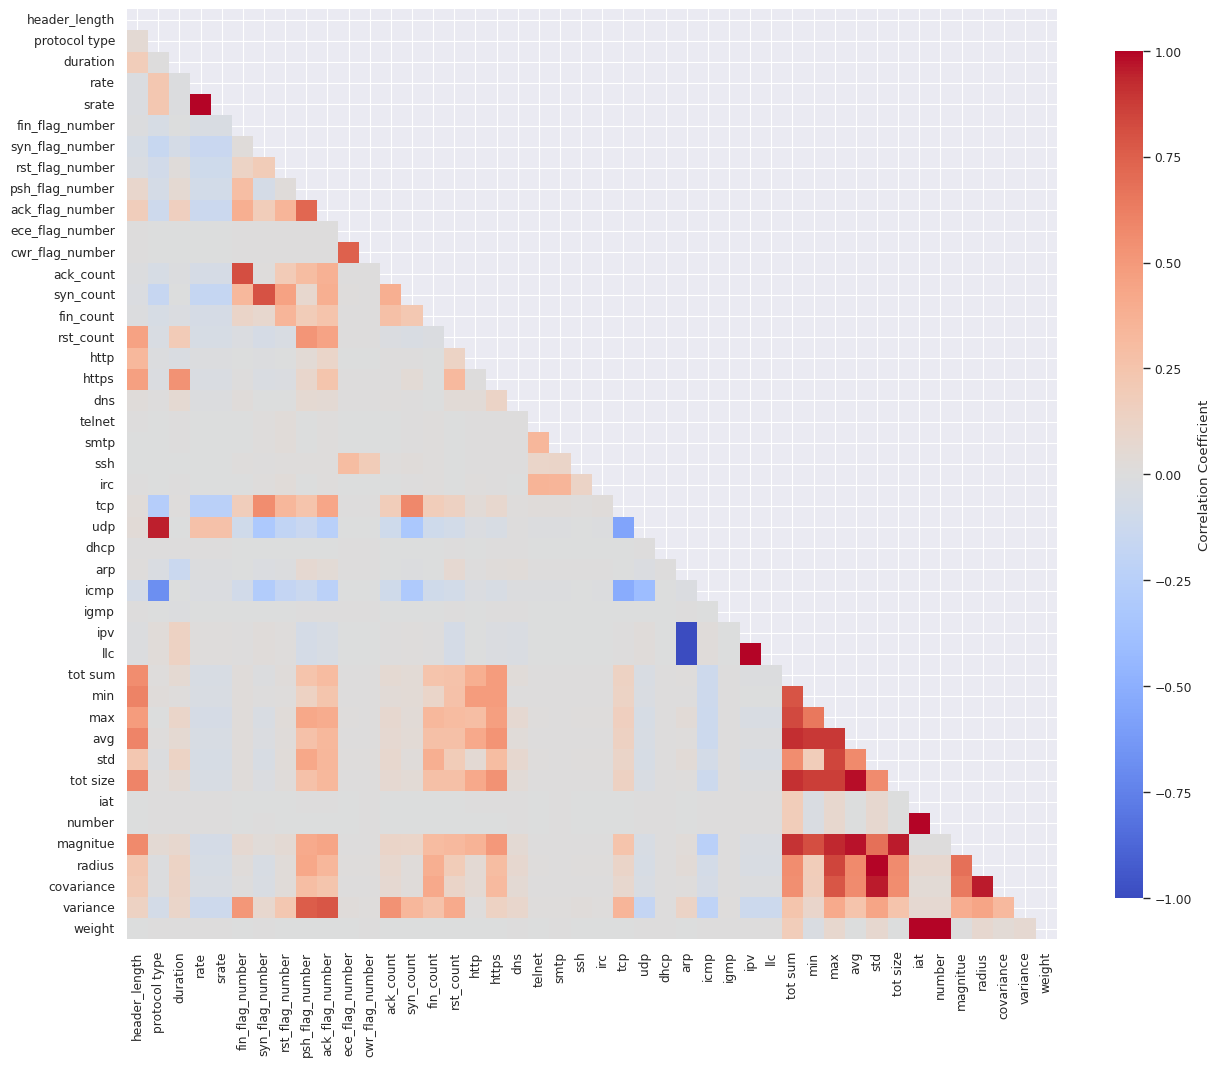

In [21]:
plot_correlation_heatmap(df)

## Preprocessing

In [22]:
from imblearn.under_sampling import RandomUnderSampler
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split

In [23]:
df = df.drop(["Name", "Attack"])
X = df.drop("Category").to_numpy()
y = df.select("Category").to_series().to_numpy()

### Splitting Data into Subsets

In [24]:
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y, test_size=0.2, random_state=0, stratify=y
)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=0.5, random_state=0, stratify=y_train_val
)

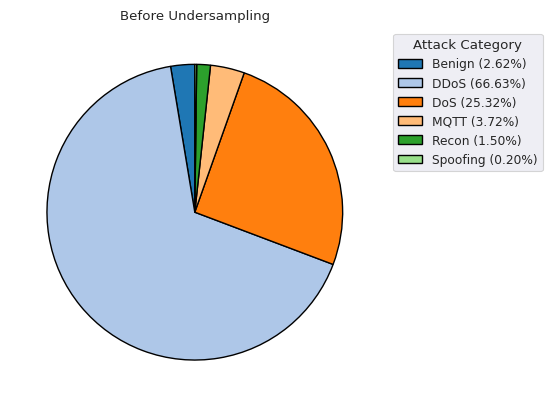

In [25]:
plot_breakdown_pie(pl.DataFrame({"Category": y_train}), "Before Undersampling")

In [26]:
rus = RandomUnderSampler(sampling_strategy={"DDoS": 300_000, "DoS": 300_000}, random_state=0)
X_train, y_train = rus.fit_resample(X_train, y_train)

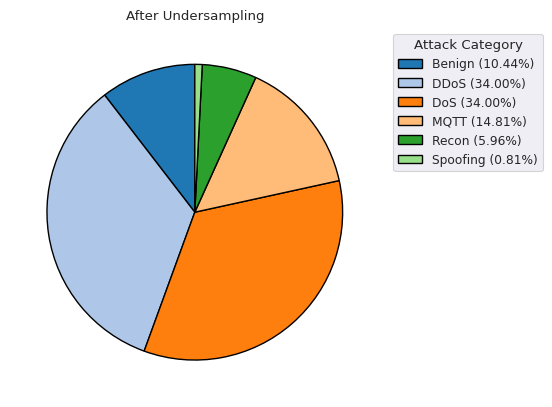

In [27]:
plot_breakdown_pie(pl.DataFrame({"Category": y_train}), "After Undersampling")

### Scaling and Labelling Data

In [28]:
encoder = LabelEncoder()
y_train = encoder.fit_transform(y_train)
y_val = encoder.transform(y_val)
y_test = encoder.transform(y_test)

In [29]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

### Feature Selection

In [30]:
X_train_df = pd.DataFrame(X_train, columns = scaler.get_feature_names_out())
corr_matrix = X_train_df.corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k =1).astype(bool))
to_drop = [col for col in upper.columns if any(upper[col] > 0.95)]

In [31]:
X_train_df = X_train_df.drop(columns=to_drop)
X_val_df = pd.DataFrame(X_val, columns= scaler.get_feature_names_out()).drop(columns=to_drop)
X_test_df = pd.DataFrame(X_test, columns= scaler.get_feature_names_out()).drop(columns=to_drop)

X_train = X_train_df.values
X_val = X_val_df.values
X_test = X_test_df.values
del X_train_df, X_val_df, X_test_df

In [32]:
print(f"Training shape: {X_train.shape}")
print(f"Validation shape: {X_val.shape}")
print(f"Testing shape: {X_test.shape}")

Training shape: (882474, 36)
Validation shape: (3510005, 36)
Testing shape: (1755003, 36)


## Model Design

In [33]:
import tensorflow as tf
from tensorflow.keras.layers import Dense, Input, BatchNormalization, Dropout
from tensorflow.keras.models import Sequential
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.models import load_model
from tensorflow.keras.optimizers import Adam

2026-02-05 01:11:50.953689: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-02-05 01:11:50.954001: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-02-05 01:11:50.986736: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-02-05 01:11:53.782609: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off,

In [34]:
def build_dnn(input_dimensions):
    model = Sequential([
        Input(shape=(input_dimensions[1],)),

        Dense(256, activation="relu"),
        BatchNormalization(),
        Dropout(0.3),

        Dense(128, activation="relu"),
        BatchNormalization(),
        Dropout(0.2),

        Dense(64, activation="relu"),
        
        Dense(6, activation="softmax")
    ])

    optimizer = Adam(learning_rate = 0.0005)
    model.compile(
        optimizer = optimizer,
        loss = "sparse_categorical_crossentropy",
        metrics = ["accuracy"]
    )
    return model

In [35]:
model = build_dnn(X_train.shape)

2026-02-05 01:11:54.428838: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [36]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │         9,472 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 52,550 (205.27 KB)

 Trainable params: 51,782 (202.27 KB)

 Non-trainable params: 768 (3.00 KB)

In [37]:
from sklearn.utils import class_weight
classes=np.unique(y_train)
weights = class_weight.compute_class_weight('balanced', classes=classes, y=y_train)
class_weights = dict(zip(classes,weights))

In [ ]:
history = model.fit(
    X_train,
    y_train,
    validation_data = (X_val, y_val),
    epochs = 50,
    batch_size=32,
    callbacks =[
        EarlyStopping(
            monitor="val_loss",
            patience = 5,
            restore_best_weights = True
        ),
        ReduceLROnPlateau(
            monitor = "val_loss",
            factor = 0.2,
            patience =3,
            min_lr = 0.00001
        )
        
    ],
)

Epoch 1/50
862/862 ━━━━━━━━━━━━━━━━━━━━ 38s 43ms/step - accuracy: 0.7003 - loss: 0.5252 - val_accuracy: 0.6805 - val_loss: 0.5926 - learning_rate: 5.0000e-04
Epoch 2/50
862/862 ━━━━━━━━━━━━━━━━━━━━ 37s 43ms/step - accuracy: 0.7451 - loss: 0.4561 - val_accuracy: 0.6833 - val_loss: 0.5475 - learning_rate: 5.0000e-04
Epoch 3/50
862/862 ━━━━━━━━━━━━━━━━━━━━ 35s 41ms/step - accuracy: 0.7527 - loss: 0.4424 - val_accuracy: 0.7096 - val_loss: 0.5285 - learning_rate: 5.0000e-04
Epoch 4/50
862/862 ━━━━━━━━━━━━━━━━━━━━ 38s 44ms/step - accuracy: 0.7561 - loss: 0.4357 - val_accuracy: 0.6916 - val_loss: 0.5403 - learning_rate: 5.0000e-04
Epoch 5/50
862/862 ━━━━━━━━━━━━━━━━━━━━ 39s 45ms/step - accuracy: 0.7589 - loss: 0.4312 - val_accuracy: 0.6988 - val_loss: 0.5207 - learning_rate: 5.0000e-04
Epoch 6/50
862/862 ━━━━━━━━━━━━━━━━━━━━ 35s 40ms/step - accuracy: 0.7599 - loss: 0.4283 - val_accuracy: 0.7097 - val_loss: 0.5166 - learning_rate: 5.0000e-04
Epoch 7/50
862/862 ━━━━━━━━━━━━━━━━━━━━ 36s 42ms/ste

In [39]:
model.save("model.keras")

In [40]:
model = load_model("model.keras")

## Model Evalutation

In [41]:
from sklearn.metrics import classification_report, f1_score

In [42]:
def plot_metrics(history):
    
    train_loss = history['loss']
    val_loss = history['val_loss']
    train_acc = history['accuracy']
    val_acc = history['val_accuracy']

    # Accuracy
    plt.figure()
    plt.plot(train_acc, label='Training Accuracy')
    plt.plot(val_acc, label='Validation Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.show()

    # Loss
    plt.figure()
    plt.plot(train_loss, label='Training Loss')
    plt.plot(val_loss, label='Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.show()

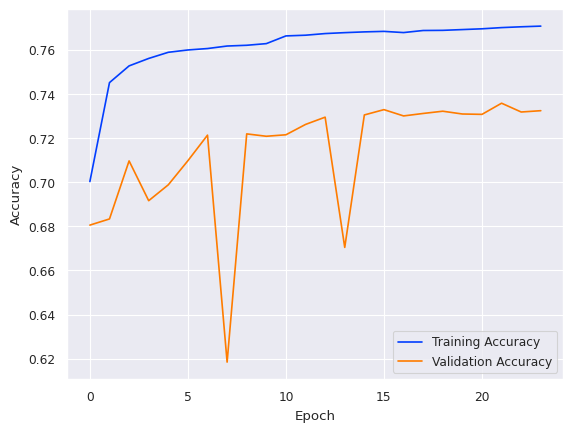

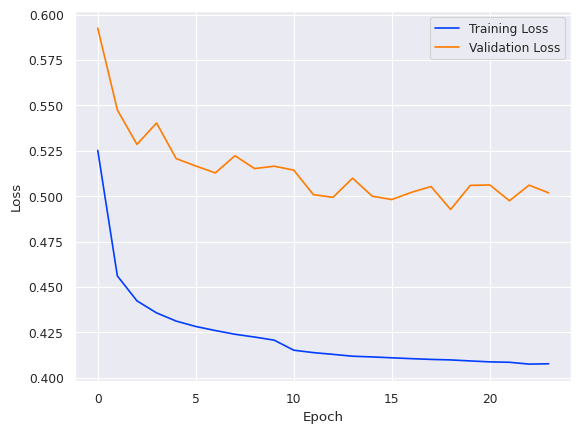

In [43]:
plot_metrics(history.history)

In [44]:
y_pred_probs = model.predict(X_test)
y_pred_classes = np.argmax(y_pred_probs, axis = 1)

54844/54844 ━━━━━━━━━━━━━━━━━━━━ 126s 2ms/step


In [45]:
print(classification_report(y_test, y_pred_classes, digits=4, target_names=encoder.classes_))

              precision    recall  f1-score   support

      Benign     0.9304    0.9818    0.9554     46068
        DDoS     0.8383    0.7461    0.7895   1169325
         DoS     0.4819    0.6213    0.5428    444441
        MQTT     0.9964    0.9880    0.9922     65331
       Recon     0.9783    0.9421    0.9599     26280
    Spoofing     0.6602    0.4848    0.5591      3558

    accuracy                         0.7321   1755003
   macro avg     0.8143    0.7940    0.7998   1755003
weighted avg     0.7581    0.7321    0.7410   1755003



In [46]:
f1_score(y_test, y_pred_classes, average="macro")

0.7998152714907937

In [ ]:
loss, accuracy = model.evaluate(X_test, y_test)
print(f"Test accuracy: {accuracy:.4f}")

10729/54844 ━━━━━━━━━━━━━━━━━━━━ 1:11 2ms/step - accuracy: 0.7321 - loss: 0.4913